In [56]:
import pandas as pd
import numpy as np
df = pd.read_csv('data/SalesPrediction.csv')
df

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181
...,...,...,...,...,...
4567,26.0,4.472360,0.717090,Micro,94.685866
4568,71.0,20.610685,6.545573,Nano,249.101915
4569,44.0,19.800072,5.096192,Micro,163.631457
4570,71.0,17.534640,1.940873,Macro,253.610411


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   object 
 4   Sales         4566 non-null   float64
dtypes: float64(4), object(1)
memory usage: 178.7+ KB


## Nhận xét  
### - Có một dữ liệu là object, cần sử dụng các kĩ thuật encoding
### - chỉ có cột thứ 3 có đầy đủ giá trị, còn lại đều chứa null


In [58]:
# hàm kiểm tra số lượng null từng feature
df.isnull().sum()

TV              10
Radio            4
Social Media     6
Influencer       0
Sales            6
dtype: int64

In [59]:
# dùng để kiểm tra các ngoại lệ thông qua một hàm số
df.describe()

,TV,Radio,Social Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [60]:
# one hot encoding
df = pd.get_dummies(df)
df

,TV,Radio,Social Media,Sales,Influencer_Macro,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,16.0,6.566231,2.907983,54.732757,False,True,False,False
1,13.0,9.237765,2.409567,46.677897,False,True,False,False
2,41.0,15.886446,2.913410,150.177829,False,True,False,False
3,83.0,30.020028,6.922304,298.246340,False,True,False,False
4,15.0,8.437408,1.405998,56.594181,False,False,True,False
...,...,...,...,...,...,...,...,...
4567,26.0,4.472360,0.717090,94.685866,False,False,True,False
4568,71.0,20.610685,6.545573,249.101915,False,False,False,True
4569,44.0,19.800072,5.096192,163.631457,False,False,True,False
4570,71.0,17.534640,1.940873,253.610411,True,False,False,False


In [61]:
# tính toán mean
df.mean()

TV                   54.066857
Radio                18.160356
Social Media          3.323956
Sales               192.466602
Influencer_Macro      0.245407
Influencer_Mega       0.253281
Influencer_Micro      0.252187
Influencer_Nano       0.249125
dtype: float64

In [62]:
# kiểm tra null
df.isnull().sum()

TV                  10
Radio                4
Social Media         6
Sales                6
Influencer_Macro     0
Influencer_Mega      0
Influencer_Micro     0
Influencer_Nano      0
dtype: int64

In [63]:
# fill null bằng mean
df = df.fillna(df.mean())
df

,TV,Radio,Social Media,Sales,Influencer_Macro,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,16.0,6.566231,2.907983,54.732757,False,True,False,False
1,13.0,9.237765,2.409567,46.677897,False,True,False,False
2,41.0,15.886446,2.913410,150.177829,False,True,False,False
3,83.0,30.020028,6.922304,298.246340,False,True,False,False
4,15.0,8.437408,1.405998,56.594181,False,False,True,False
...,...,...,...,...,...,...,...,...
4567,26.0,4.472360,0.717090,94.685866,False,False,True,False
4568,71.0,20.610685,6.545573,249.101915,False,False,False,True
4569,44.0,19.800072,5.096192,163.631457,False,False,True,False
4570,71.0,17.534640,1.940873,253.610411,True,False,False,False


In [64]:
df.isnull().sum()

TV                  0
Radio               0
Social Media        0
Sales               0
Influencer_Macro    0
Influencer_Mega     0
Influencer_Micro    0
Influencer_Nano     0
dtype: int64

In [65]:
# xét mối tương quan tuyến tính
df.corr()

,TV,Radio,Social Media,Sales,Influencer_Macro,Influencer_Mega,Influencer_Micro,Influencer_Nano
TV,1.000000,0.866885,0.527010,0.996652,0.021335,-0.012630,-0.004863,-0.003645
Radio,0.866885,1.000000,0.606793,0.867369,0.009518,-0.005071,0.004212,-0.008601
Social Media,0.527010,0.606793,1.000000,0.528121,0.011631,0.013072,-0.013312,-0.011351
Sales,0.996652,0.867369,0.528121,1.000000,0.019267,-0.011701,-0.004099,-0.003289
Influencer_Macro,0.021335,0.009518,0.011631,0.019267,1.000000,-0.332131,-0.331171,-0.328482
Influencer_Mega,-0.012630,-0.005071,0.013072,-0.011701,-0.332131,1.000000,-0.338211,-0.335465
Influencer_Micro,-0.004863,0.004212,-0.013312,-0.004099,-0.331171,-0.338211,1.000000,-0.334495
Influencer_Nano,-0.003645,-0.008601,-0.011351,-0.003289,-0.328482,-0.335465,-0.334495,1.000000


### Nhận xét về cột sales:
- TV và sales có độ tương quan rất cao nên có thể biểu diễn tuyến tính  
- Radio và Sales cũng rất cao, có thể biểu diễn thành tuyến tính  
- Social Media ở mức trung bình, có tương quan nhưng ít hơn  
- 4 cột biểu diễn được từ one-hot thì hầu như không có thông tin, vì đều có giá trị 0 hoặc 1.

In [66]:
import numpy as np
import seaborn as sns
import matplotlib as plt

<Axes: >

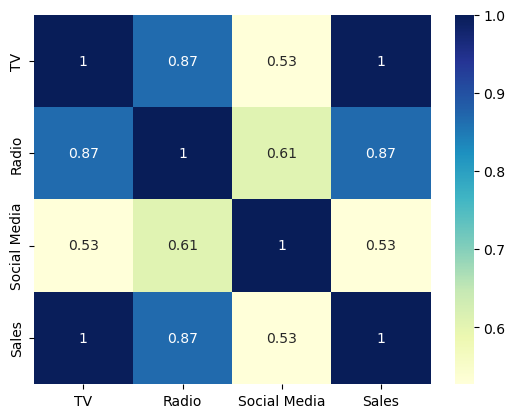

In [67]:
# biểu diễn heatmap của correlation trên 4 cột chính: TV, Radio, Social Media, Sales
# Các tham số: 'cmap': colormap, với 'YlGnBu' là màu xanh hiện đại
# 'numeric_only' trong 'corr': an toàn: chỉ lấy những cột số để thực hiện colloration
# 'annot': anootation, hiển thị các thông số trên heatmap 
new_df = df[['TV', 'Radio', 'Social Media', 'Sales']]
sns.heatmap(new_df.corr(numeric_only=True), cmap='YlGnBu', annot=True)


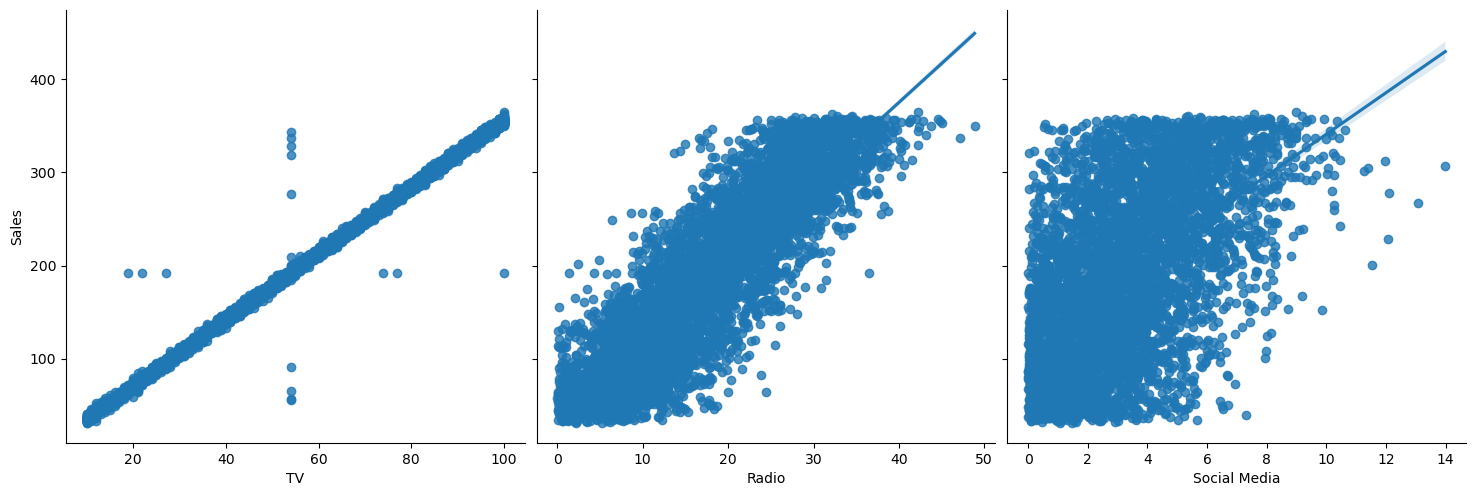

In [68]:
# plot tuyến tính của sales và các features ứng viên
sns.pairplot(data=df,
             x_vars=['TV', 'Radio', 'Social Media'],
             y_vars=['Sales'],
             height=5,
             kind='reg')

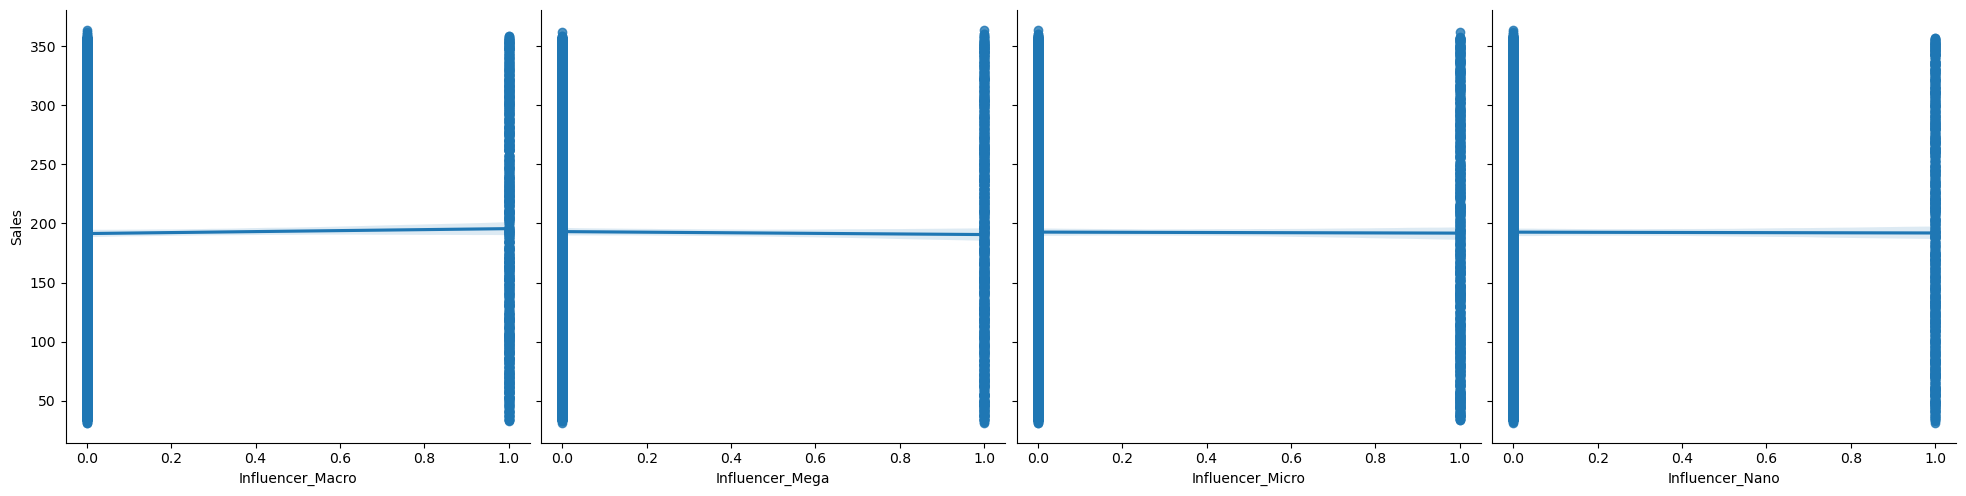

In [69]:
# plot seaborn các ứng viên còn lại, cho thấy tính chất rõ ràng: chỉ có 0 và 1.
sns.pairplot(data=df,
             x_vars=['Influencer_Macro', 'Influencer_Mega',	'Influencer_Micro', 'Influencer_Nano'],
             y_vars=['Sales'],
             height=5,
             kind='reg')

### Kết thúc pre-processing. Chia thành tập training và tập test

In [70]:
# X gồm tất cả các cột trừ Sales. Y là Sales.
X = df[['TV', 'Radio', 'Social Media', 'Influencer_Macro', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']]
X.head()

,TV,Radio,Social Media,Influencer_Macro,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,16.0,6.566231,2.907983,False,True,False,False
1,13.0,9.237765,2.409567,False,True,False,False
2,41.0,15.886446,2.913410,False,True,False,False
3,83.0,30.020028,6.922304,False,True,False,False
4,15.0,8.437408,1.405998,False,False,True,False


In [71]:
y = df[['Sales']]
y.head()

,Sales
0,54.732757
1,46.677897
2,150.177829
3,298.246340
4,56.594181


In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

In [73]:
# kiểm tra shape của các cặp train và test
X_train.shape, y_train.shape

((3063, 7), (3063, 1))

train có 7 feature, 3063 dòng. đủ

In [74]:
X_test.shape, y_test.shape

((1509, 7), (1509, 1))

## Chuẩn hóa lại dữ liệu bằng Standard Scaler

In [105]:
from sklearn.preprocessing import StandardScaler

# học và huấn luyện X_train scale thành X_train_scaled
model = StandardScaler()
X_train_scaled = model.fit_transform(X_train)
print(model.mean_[0])
# chỉ transform tập test, không cho X_test nhìn
X_test_scaled = model.transform(X_test)

53.85123548260174


In [76]:
X_train_scaled.shape, X_test_scaled.shape

((3063, 7), (1509, 7))

In [77]:
class CustomLinearRegression:
    def __init__(self, X_data, y_target, learning_rate=0.01, num_epochs=10000):
        self.num_samples = X_data.shape[0]  # N
        self.num_features = X_data.shape[1]  # M
        self.X_data = np.c_[np.ones((self.num_samples, 1)), X_data]  # (N, D)
        self.y_target = y_target           # (N, 1)
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs

        # initial weight 
        self.theta = np.random.randn(self.X_data.shape[1], 1) # (D, 1)
        self.losses = []

    def compute_loss(self, y_pred, y_target):
        loss = np.mean(1/2*np.multiply((y_target - y_pred), (y_target - y_pred)))
        return loss
    
    # custom việc thêm np.ones khi chưa thêm ở ngoài class
    def predict(self, X_data):
        if self.theta.shape[0] == X_data.shape[1]:
            y_pred = X_data.dot(self.theta) # X: (N, D), theta: (D, 1)
        else:
            X_data = np.c_[np.ones((X_data.shape[0], 1)), X_data]
            y_pred = X_data.dot(self.theta)  # X: (N, D), theta: (D, 1)

        return y_pred

    def fit(self):
        for epoch in range(self.num_epochs):
            y_pred = self.predict(self.X_data)  # (N, 1)
            loss_value = self.compute_loss(y_pred, self.y_target)
            self.losses.append(loss_value)
            k = (y_pred - self.y_target)  # (N, 1)
            dl = self.X_data.T.dot(k)/self.num_samples  # (D, 1)
            self.theta = self.theta - self.learning_rate*dl
 
            if (epoch % 50) == 0:
                print(f"Epoch: {epoch} - Loss: {loss_value}")
      
        return {
            'loss': sum(self.losses)/len(self.losses),
            'weight': self.theta
        }


In [78]:
model = CustomLinearRegression(X_train_scaled, y_train)
model.fit()

Epoch: 0 - Loss: 22882.827800251856
Epoch: 50 - Loss: 7564.238193001931
Epoch: 100 - Loss: 2852.399396535893
Epoch: 150 - Loss: 1179.720665877899
Epoch: 200 - Loss: 550.3319782240595
Epoch: 250 - Loss: 302.51068805589523
Epoch: 300 - Loss: 198.29966441348841
Epoch: 350 - Loss: 149.66808276003385
Epoch: 400 - Loss: 123.4881445468106
Epoch: 450 - Loss: 107.03532432204585
Epoch: 500 - Loss: 95.2651094613315
Epoch: 550 - Loss: 86.07499600353157
Epoch: 600 - Loss: 78.51993587485234
Epoch: 650 - Loss: 72.12894693716736
Epoch: 700 - Loss: 66.63684425229366
Epoch: 750 - Loss: 61.875069597527094
Epoch: 800 - Loss: 57.7249991674282
Epoch: 850 - Loss: 54.09664834892888
Epoch: 900 - Loss: 50.91818840460878
Epoch: 950 - Loss: 48.130337826320144
Epoch: 1000 - Loss: 45.683100135783484
Epoch: 1050 - Loss: 43.53371127639315
Epoch: 1100 - Loss: 41.64525374028592
Epoch: 1150 - Loss: 39.98566208546108
Epoch: 1200 - Loss: 38.526972115058655
Epoch: 1250 - Loss: 37.24473038814245
Epoch: 1300 - Loss: 36.11751

{'loss': 141.63283965920206,
 'weight': array([[ 1.91695036e+02],
        [ 9.15894858e+01],
        [ 1.22922019e+00],
        [ 1.26273147e-01],
        [-7.56016408e-01],
        [-5.40167131e-01],
        [-6.17949657e-01],
        [-5.91984939e-01]])}

In [79]:
# bây giờ, model được fit có thể đi dự đoán.
pred = model.predict(X_test_scaled)
pred

array([[ 74.17081798],
       [ 85.10626809],
       [292.69404277],
       ...,
       [284.41945968],
       [192.34423934],
       [ 90.69842358]])

In [80]:
from sklearn.metrics import r2_score
r2_score(y_test, pred)

0.9929967451823754

In [81]:
X_test.shape, y_test.shape

((1509, 7), (1509, 1))

### Sử dụng thư viện

In [82]:
from sklearn.linear_model import LinearRegression

model_linear = LinearRegression()
model_linear.fit(X_train_scaled, y_train)

LinearRegression()

In [83]:
predicted = model_linear.predict(X_test_scaled)
r2_score(y_test, predicted)

0.9929967461773731

### Sử dụng Polynominal 

In [90]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2)

# polynominal cho X_train
X_train_poly = poly_features.fit_transform(X_train)

In [91]:
X_train_poly.shape, X_train.shape

((3063, 36), (3063, 7))

In [92]:
# polynominal cho X_test
X_test_poly = poly_features.transform(X_test)

In [93]:
X_test_poly.shape, X_test.shape

((1509, 36), (1509, 7))

In [94]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [95]:
pred_poly = poly_model.predict(X_test_poly)
r2_score(y_test, pred_poly)

0.9929224151097563

### Trắc nghiệm

1. A  
2. C  
3. D
4. B  
5. B
6. B
7. A  
8. D
9. A  
10. A

In [98]:
def customR2Score(y_pred, y):
    rss = np.sum((y_pred - y)**2)
    tss = np.sum((y - y.mean())**2)
    r2 = 1 - (rss/tss)
    return r2

y_pred = np.array([1, 2, 3, 4, 5])
y = np.array([1, 2, 3, 4, 5])
customR2Score(y_pred, y)

1.0

In [102]:
y_pred = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 5, 2, 4])
customR2Score(y_pred, y)

-2.235294117647059